
# Interactive Lecture:  $J/\psi $ 2-Muon Decay in CMS Experiment

## Introduction to CMS Experiment

The Compact Muon Solenoid (CMS) is a general-purpose detector at the Large Hadron Collider (LHC) at CERN. It is designed to investigate a wide range of physics, including the search for the Higgs boson, extra dimensions, and particles that could make up dark matter. The CMS detector is particularly adept at detecting muons, which are heavier cousins of electrons.

<img src="img/detector_slice.svg" width="760"/>

### Understanding Decay particles

In particle physics, muons are elementary particles similar to electrons but with a much greater mass. They are often produced in high-energy collisions and can decay into other particles. 

1. Analyze data from the CMS experiment 

2. Calculate the invariant mass of the muon pairs to identify potential parent particles.
3. Fit the invariant mass distribution to extract physical parameters.

Let's get started by exploring the CMS event display and understanding the data we will be working with.
But first, a video of collision: 

https://home.cern/resources/video/physics/z-muon-muon-collision-event-animation


In [1]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/5xcw7sU_jkg?si=GiD_EMF_JoWCMxR8" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

## CMS Event Display

An event display is a graphical representation of the data collected from particle collisions, showing the trajectories and interactions of particles within a detector. It helps physicists visually analyze and interpret complex collision events to identify and study various particles and their properties.


In [2]:
%%html
<iframe src="https://ispy-webgl-masterclass.web.cern.ch/" width="1100" height="650"></iframe>

## Interactive CMS slice

Which particle leaves which trace? Choose a particle in the slice below and watch it fly through the layers of CMS, from the collision point in the middle to the muon chambers on the outside (the same layers as in the picture above).

**Question**: which particles get all the way out? Which ones stop in the calorimeters, and which leave no track at all?


In [3]:
%%html
<iframe src="https://cmsslice.web.cern.ch/" width="1100" height="650"></iframe>

## $J/\psi $ decay - charm-anticharm final state


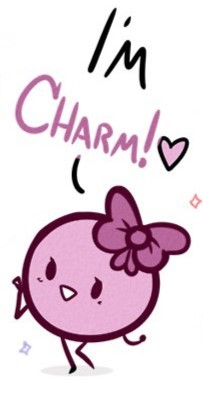 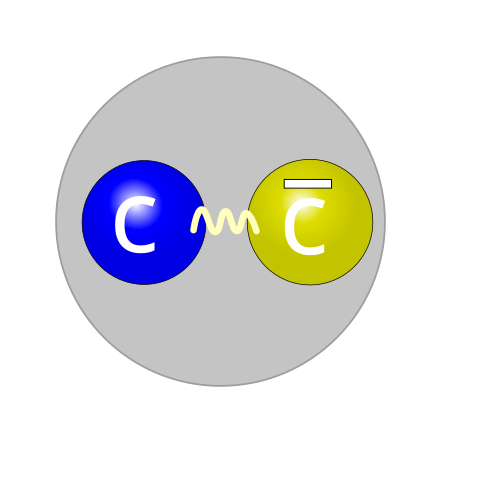


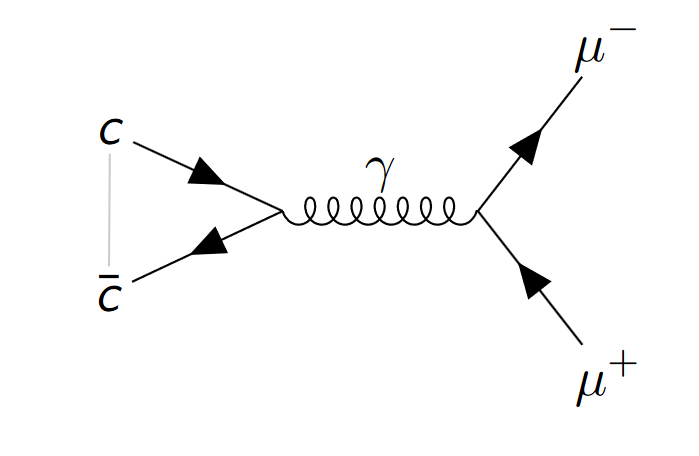

## Introduction to Particle Physics


### Why We Use Momentum to Describe Particles

1. **High Speeds (Relativity)**:
   - Particles in high-energy experiments move near the speed of light.
2. **Conservation Laws**:
   - In particle collisions, **momentum** and **energy** are conserved.
3. **Wave-Particle Duality**:
   - Particles can behave both like particles and waves. Their momentum tells us about their wave properties, like wavelength...
   
### Interlude - why we use $p_T$, $\eta$ and $\phi$ 
<img src="img/coordinates.svg" width="640"/>

#### The coordinate system of a collider

The two proton beams travel along one straight line, in opposite directions. We call that line the **z-axis** and put the origin where the beams cross; the **x-y plane** is then **transverse** (perpendicular) to the beams.

Only one quark or gluon from inside each proton takes part in the collision, carrying an unknown fraction of its proton's momentum. So we never know the total momentum along $z$ before the collision, and most of it escapes down the beam pipe afterwards. Transverse to the beam we do know it: the beam particles travel almost exactly along $z$, so their $p_x$ and $p_y$ are zero, the total transverse momentum starts at zero and must still be zero after. The sideways momentum gets its own name, $p_T$; $p_z$ does not.

### **$p_T , \eta, \phi \Leftrightarrow  p_x, p_y,p_z$**

We use three main quantities to describe particles in high-energy physics:
1. **Transverse Momentum ($ p_T $)**:
   - This is the momentum of a particle in the plane **perpendicular** to the direction of the particle beams in a collider.
   - Formula: $ p_T = \sqrt{p_x^2 + p_y^2} $
   - It tells us how fast the particle is moving sideways from the beamline.

2. **Pseudorapidity ($ \eta $)**:
   - Instead of using the z-axis momentum, we use $ \eta $, which describes how far the particle is from the beam axis (z-direction).
   - Formula: $ \eta = -\ln \left( \tan \frac{\theta}{2} \right) $ (where $ \theta $ is the angle from the beam).
   - Why use rapidity instead of the angle? Well, it turns out that particle production in collisions is roughly constant as a function of rapidity, which makes things very nice. Also, differences in (pseudo)rapidity are Lorentz invariant, unlike differences in the angle.

<img src="img/pseudorapidity.svg" width="520"/>

3. **Azimuthal Angle ($ \phi $)**:
   - This is the angle the particle makes in the **x-y plane** around the beamline.
   - Formula: $ \phi = \arctan2(p_y, p_x) $
   - It tells us the direction the particle is moving in the plane perpendicular to the beam.

#### What "Lorentz invariant" means

A **reference frame** is just the point of view of one observer. Ours is the **lab frame**: we sit still next to the CMS detector and measure the muons. An observer flying along the beam at high speed measures a different $p_z$, energy and angle $\theta$ for the same muon. Neither of us is wrong.

A quantity that comes out the same number for every observer is called **Lorentz invariant**. Look at the picture above: turn the axes and $p_x$, $p_y$ and $p_z$ all change, but the length of the arrow, $\sqrt{p_x^2 + p_y^2 + p_z^2}$, stays the same. Moving fast along the beam is the relativistic version of turning the axes. We will use this idea later today: the **invariant mass** is what tells us which particle the two muons came from.

For $\eta$ concretely: an observer moving along the beam adds the same constant to the $\eta$ of every particle, so in the difference $\eta_1 - \eta_2$ that constant cancels. The opening **angle** between the two muons does not survive this: the moving observer sees every track pushed towards the beam. (Strictly it is the **rapidity** that shifts by the same constant; $\eta$ is its massless version, and our muons here are fast enough that the two agree.)

      



   



| **Variables in High Energy Physics** | **Traditional Cartesian Variables** | **Formula**                                     |
|--------------------------------------|-------------------------------------|-------------------------------------------------|
| $ p_T $ (transverse momentum)      | $ p_x, p_y $                      | $ p_T = \sqrt{p_x^2 + p_y^2} $                |
| $ \eta $ (pseudorapidity)          | $ p_z $                             | $ \eta = -\ln \left( \tan \frac{\theta}{2} \right) $ where $ \theta = \arctan \frac{p_T}{p_z} $ |
| $ \phi $ (azimuthal angle)         | —                                                | $ \phi = \arctan2(p_y, p_x) $                |


## Hands-on
### Loading data

In [4]:
import ROOT
ROOT.gStyle.SetOptFit(1111)

In [5]:
import os
csv_file = "data/Jpsimumu.csv" # local copy of the CMS Open Data file (https://opendata.cern.ch/record/5203)
if not os.path.exists(csv_file): # if the local copy is missing, read it directly from CERN instead
    csv_file = "https://opendata.cern.ch/record/5203/files/Jpsimumu.csv"

data = ROOT.RDF.FromCSV(csv_file) # load data from COMMA SEPARATED FILE (CSV) file
data.Snapshot('my_tree', 'my_data.root') # save the loaded data into file my_data.root on disk

<cppyy.gbl.ROOT.RDF.RResultPtr<ROOT::RDF::RInterface<ROOT::Detail::RDF::RLoopManager,void> > object at 0x432588a0>

In [6]:
#  Just for drawing a table nicely
import pandas
dataset = pandas.read_csv(csv_file)
dataset.head(10) # Show the first 10 rows of the dataset

,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
0,165617,75206813,G,10.1623,0.4763,-8.5164,5.5231,8.5297,0.6091,-1.5149,-1,G,19.7754,2.7508,-13.9871,13.7059,14.2550,0.8539,-1.3766,1
1,165617,75678475,G,15.8799,15.0618,-1.6658,-4.7464,15.1536,-0.3083,-0.1102,1,G,11.9338,11.9084,-0.7670,-0.0851,11.9330,-0.0071,-0.0643,-1
2,165617,74428554,G,21.8279,-6.2214,11.0845,17.7447,12.7111,1.1357,2.0823,-1,G,36.6513,-10.6874,15.0692,31.6544,18.4743,1.3076,2.1877,1
3,165617,75193169,G,19.4923,2.7612,-5.5769,-18.4719,6.2230,-1.8084,-1.1111,1,G,14.9334,1.5525,-6.1254,-13.5302,6.3190,-1.5050,-1.3226,-1
4,165617,74832715,G,8.0972,4.6127,-1.8389,6.3949,4.9657,1.0710,-0.3793,-1,T,3.5131,-0.5305,0.6880,3.4024,0.8688,2.0742,2.2276,1
5,165617,74981507,G,30.5862,15.5218,5.1293,-25.8509,16.3474,-1.2391,0.3192,1,G,12.4868,7.7640,1.0425,-9.7233,7.8337,-1.0421,0.1335,-1
6,165617,75612982,G,7.5544,1.2913,-5.3588,-5.1646,5.5122,-0.8361,-1.3343,-1,T,3.8416,-0.9896,-3.4548,-1.3534,3.5938,-0.3682,-1.8498,1
7,165617,74760204,G,24.6376,9.9836,19.1426,-11.8697,21.5896,-0.5253,1.0901,1,G,11.0213,3.3785,7.8272,-6.9841,8.5252,-0.7476,1.1633,-1
8,165617,75017052,G,22.5057,5.6296,-9.9497,19.3857,11.4319,1.2987,-1.0559,1,G,30.5709,4.9468,-13.6360,26.9102,14.5055,1.3769,-1.2228,-1
9,165617,75204668,G,10.7051,-8.4664,-2.2374,-6.1564,8.7571,-0.6551,-2.8832,1,G,55.1896,-45.0429,-16.6152,-27.2205,48.0096,-0.5403,-2.7882,-1


Each line contains a single Event with 2 detected muons:

|**Run number**|**Event number**|Muon1 Info|Muon2 Info|
| -------- | ------- |-------- | ------- |


The kinematic properties of the muons are stored in columns. 
For the "first" muon they are called `Q1, E1, px1, py1, pz1, pt1, eta1, phi1,` and for the "second" one `Q2, E2, px2, py2, pz2, pt2, eta2, phi2`.


**Muon Info**:
|Variable|Description|
| -------- | ------- |
|**type** |	Either T or G: whether the muon is a tracker or global muon|
|**E** |	The total energy of the muon (GeV)|
|**px,py,pz**| 	The components of the momemtum of the muon (GeV/*c*)|
|**pt** |	The transverse momentum of the muon (GeV/*c*)|
|**eta** |	The pseudorapidity of the muon|
|**phi** |	The phi angle of the muon (rad)|
|**Q** |	The charge of the muon|


## Interlude
### Derivation of energy-momentum relation

In Einstein’s equation, $E = m_0c^2$, $m_0$ is the **rest mass** of an object

However, when an object is moving, its energy has both a rest mass component and a kinetic component. The full energy-momentum relation in special relativity accounts for both rest mass and momentum, which we aim to derive.

In special relativity, the **momentum** $p$ of an object with **rest mass** $m_0$ and **velocity** $v$ is given by:
$$ p = mv= \gamma m_0 v $$
And **energy** is:
$$ E = mc^2=\gamma m_0 c^2 $$
where $\gamma$ is the **Lorentz factor**:
$$ \gamma = \frac{1}{\sqrt{1 - \frac{v^2}{c^2}}} $$

#### What the Lorentz factor is

$\gamma$ is a pure number: the only thing inside the formula is $v/c$, a speed divided by a speed. It answers one question: how close to the speed of light is this object?

An object at rest has $v = 0$ and $\gamma = 1$, so its energy is just $E = m_0c^2$. Anything above that, $(\gamma - 1)m_0c^2$, is the kinetic energy, and at small speeds it reduces to the $\frac{1}{2}m_0v^2$ you know from mechanics. But as $v$ approaches $c$ the denominator approaches zero and $\gamma$ grows without limit:

|$v/c$|$\gamma$|
| -------- | ------- |
|0.1|1.005|
|0.5|1.155|
|0.9|2.294|
|0.99|7.089|
|0.999|22.37|
|0.99999|223.6|

At $v = c$ the formula gives infinity: **an object with mass can never reach the speed of light**, because that would take infinite energy. Only massless things (photons) travel at $c$.

<details>
<summary><b>Learn more about the Lorentz factor</b></summary>

**Question**: an accelerator speeds a particle up from $0.99c$ to $0.99999c$. By what factor does its energy have to grow? How much faster does the particle actually go?

<details>
<summary>Click for answer</summary>

$\gamma$ grows from 7.089 to 223.6, so the energy grows by a factor of 31.5. The speed grows by $0.00999\,c$, about one part in a hundred. Near $c$, almost all the energy goes into $\gamma$ and almost none into speed.
</details>

The same $\gamma$ is the **time dilation** factor: a moving clock ticks $\gamma$ times slower as seen from the laboratory. A muon at rest lives on average $2.2$ microseconds, which even at the speed of light is only 660 m of travel, so a muon born 15 km up in the atmosphere should never reach the ground. Cosmic-ray muons arrive at sea level in large numbers anyway. A muon with $\gamma \approx 30$ lives $30 \cdot 2.2 = 66$ microseconds in our frame, which is 20 km. The muon is not doing anything special; our clock and its clock disagree.

And what is $\gamma$ for the muons in **our** data? A muon has a rest mass of $0.1057$ GeV/$c^2$, and in this dataset a typical muon carries about 12 GeV of energy, so
$$ \gamma = \frac{E}{m_0c^2} \approx \frac{12}{0.1057} \approx 114 $$
and $v = 0.99996\,c$. At that $\gamma$, $E$ and $pc$ differ by less than one part in $10^{4}$: almost all of the muon's energy is motion, and only $0.1$ GeV of it is rest mass.

</details>

---
Let's square the **Lorentz factor**:
$$ \gamma ^2  = \frac{c^2}{c^2 - v^2} $$
$$ \gamma ^2 v^2 = \gamma ^2 c^2 - c^2 $$

Let's square the **momentum** relation:
$$ p^2 = \gamma^2 m_0^2 v^2 = m_0^2 \gamma^2 v^2 =  m_0^2 ( \gamma ^2 c^2 - c^2) $$
Open brackets and multiply by $c^2$
$$  p^2 c^2 = m_0^2 \gamma ^2 c^4 - m_0^2 c^4  = E^2 - m_0^2 c^4 $$

Substituting this back into our expression for $E^2$, we arrive at the full energy-momentum relation:
$$ E^2 = (m_0c^2)^2 + (pc)^2 $$
This equation represents the relationship between energy, momentum, and rest mass for any particle in special relativity.

## Natural units $c=1$

Due to the convention of natural units in physics the speed of light is equal to 1. Why? Not to waste time on managing degrees of $c$ and concentrate on actual dependencis since it can be backtraced.

$$ E^2 = m_0^2 + p^2 $$

## Invariant mass $M$
Particles have a mass that describes their inertia. It is the same mass $m$ that is used in Newton’s second law and Einstein’s equation $E=mc^2$. It is impossible to measure e.g. $J/\psi$ meson, whose mean lifetime is in the order of $ 10^{-21} $ seconds. However, a detector can measure the momentum and energy of its decay particles, from which we can calculate the invariant mass. It is a property that is “invariant” to the environment it’s measured in. 
Example: $ J/\psi \rightarrow \mu^+\mu^-$ 

<img src="img/jpsi_decay.svg" width="520"/>

- Invariant mass is a mathematical concept, not a physical mass.

- Invariant mass is conserved when a particle decays into other particles. A detector detects mostly stable particles. 

- We can calculate the invariant mass to multiple different events and make a histogram out of our calculated values.



The invariant mass of the two particles **1** and **2** is determined by the equation

$$ M = \sqrt{(E_1 + E_2)^2-(\vec{p_1} + \vec{p_2})^2}, $$

where $E_1$ and $E_2$ are the energies of the decay products and $\vec{p_1}$ and $\vec{p_2}$ the momenta of the decay products.
In a collider we never measure $M$ directly: we measure the two muons and add them up.


In [7]:
tree     = ROOT.TChain("my_tree") # create a TChain object to read the data from the file
tree.Add("my_data.root") # load the data from the file to existing TChain
n_events = tree.GetEntries() # get the number of events in the dataset
print("Number of events in the dataset: ", n_events)
tree.Show(0) # show the first event in the dataset

Number of events in the dataset:  20000
======> EVENT:0
 Run             = 165617
 Event           = 75206813
 type1           = G
 E1              = 10.1623
 px1             = 0.4763
 py1             = -8.5164
 pz1             = 5.5231
 pt1             = 8.5297
 eta1            = 0.6091
 phi1            = -1.5149
 Q1              = -1
 type2           = G
 E2              = 19.7754
 px2             = 2.7508
 py2             = -13.9871
 pz2             = 13.7059
 pt2             = 14.255
 eta2            = 0.8539
 phi2            = -1.3766
 Q2              = 1


In [8]:
# define the histogram
x_low   = 2 # GeV/c^2 - lower limit of the histogram
x_up    = 4 # GeV/c^2 - upper limit of the histogram
n_bins  = 200 # number of bins
x_title = "M_{#mu#mu} [GeV/c^{2}]" # x-axis
y_title = "Events" # y-axis
title   = "Dimuon mass" # title of the histogram

hist    = ROOT.TH1F("hist", title + ";" +  x_title + ";" + y_title, n_bins, x_low, x_up) # create the histogram

### Example of a histogram:
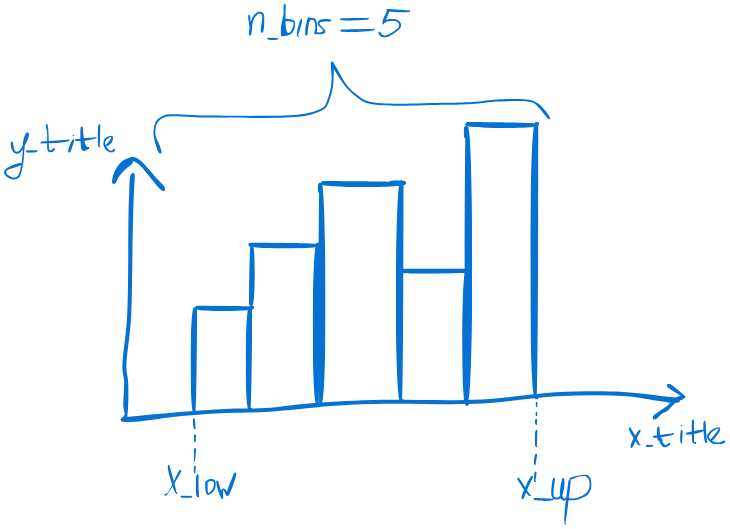

### Fill our histogram, using the 4D Lorentz vectors $(E,p_x,p_y,p_z)$ of the two muons


In [9]:
import math # we will need it later

hist.Reset() # empty the histogram, in case this cell is run twice
for i in range(n_events): # loop over all events
    tree.GetEntry(i) # read the i-th event in the tree

    muon1 = ROOT.TLorentzVector() # a four-vector (E, px, py, pz) for the first muon
    muon1.SetPxPyPzE(tree.px1, tree.py1, tree.pz1, tree.E1) # fill it from the data

    muon2 = ROOT.TLorentzVector() # and one for the second muon
    muon2.SetPxPyPzE(tree.px2, tree.py2, tree.pz2, tree.E2)

    dimuon = muon1 + muon2 # ALL THE MAGIC HAPPENS HERE: four-vectors simply add up
    hist.Fill( dimuon.M() ) # AND HERE: .M() is exactly the formula above


### Let's plot it
`%jsroot on` line is for activating nice interactive visuals

In [10]:
%jsroot on
can = ROOT.TCanvas() # create a canvas
can.Draw() # draw the canvas
hist.Draw("E1") # draw the histogram with error bars  ("E1")

**Question**:
- What does the histogram tell us?
- What happens around the mass 3.1 GeV/$c^2$?

<img src="img/histogram_anatomy.svg" width="600"/>


### Where do the error bars come from?

The option `"E1"` adds a vertical bar to every point. Each bin is a **count**: how many times `hist.Fill()` was called with a mass inside that bin. So why does a count need an error bar?

Every collision in the file is independent of every other one, and each one has a small chance of landing in this particular bin. If the LHC ran again for the same amount of time we would get a different histogram: the same shape, but every bin on a slightly different number. The error bar is our estimate of how much a bin would move.

Counting independent rare events at a constant average rate has a name: the **Poisson distribution**. It answers the question "how many things happened?" - how many clicks a Geiger counter makes in one second next to a lump of uranium, or how many muon pairs land in the bin from 3.09 to 3.10 GeV/$c^2$.

From Poisson we need one fact: **if the average number of entries in a bin is $N$, the typical fluctuation around that average is $\sqrt{N}$.** Each collision wobbles the count in a random direction, so the wobbles mostly cancel instead of piling up: the count grows in proportion to the number of collisions, its spread only like the square root of it.


**Question**: 
what is the statistical error in this case (assuming Poisson distribution for bins)?

<details>
<summary>Click for answer</summary>

If a bin contains $N$ entries (i.e. it was `fill`ed $N$ times), then

$$ \sigma_N = \sqrt{N} $$

This is the **absolute** uncertainty, in entries: the bar `"E1"` draws runs from $N - \sqrt{N}$ up to $N + \sqrt{N}$.

The **relative** (fractional) uncertainty is that error divided by the count itself:

$$ \frac{\sigma_N}{N} = \frac{\sqrt{N}}{N} = \frac{1}{\sqrt{N}} $$

Look at your plot: the tallest bin holds 1270 entries, so its bar is $\sqrt{1270} \approx 36$ entries, about 2.8 %. A bin out at 2.5 GeV/$c^2$ holds 58 entries, so its bar is $\sqrt{58} \approx 7.6$ entries, about 13 %. The tall bin has the longer bar on the screen and the smaller uncertainty in percent.

This is a **statistical** uncertainty: it comes only from having a finite number of collisions.
</details>

### Follow-up:
- Imagine 100 events in a bin, what is the uncertainty in percents? 
- How much more events is needed to reduce statistical uncertainty by factor of 2?

<details>
<summary>Click for answer</summary>

**100 events in a bin.** The absolute uncertainty is $\sqrt{100} = 10$ entries, so the bin is $100 \pm 10$. As a fraction that is $1/\sqrt{100} = 0.1$, i.e. **10 %**.

**Halving the uncertainty.** The relative uncertainty is $1/\sqrt{N}$, so to make it 2 times smaller we need $\sqrt{N}$ to be 2 times bigger, which means **4 times more events**. That is why the LHC does not run for a week but for years.
</details>


## Let's try to fit the peak and see how many $J/\psi$ mesons there are

<img src="img/curve_fitting_2x.png" width="500"/>


https://xkcd.com/2048


We will use a Gaussian function
$f(x)=A\cdot  \exp\left( - \frac{(x-\mu)^2}{2\sigma^2}\right)$

### The three parameters $A$, $\mu$ and $\sigma$

A Gaussian is fixed by three numbers, and the fit finds all three. Only one is a property of the $J/\psi$.

| Parameter | What it is on the plot | What it means in this measurement |
| -------- | ------- | ------- |
| $A$ | the height of the curve at its top | roughly the height of the peak above the background, in events per bin. Collect twice as much data and $A$ doubles |
| $\mu$ | the position of the centre of the peak on the $x$ axis | our **measurement of the $J/\psi$ mass**, in GeV/$c^2$. This single number is what the whole notebook is after |
| $\sigma$ | how far the peak spreads out from its centre | how precisely the detector measured the two muons. Here $\sigma$ is almost entirely **detector resolution**, not a property of the $J/\psi$ |

$\sigma$ is measured in GeV/$c^2$, like the mass itself, and gives a rule of thumb:

- $68\%$ of all the events under the curve lie within $\mu \pm 1\sigma$,
- $95\%$ within $\mu \pm 2\sigma$,
- $99.7\%$ within $\mu \pm 3\sigma$.

This is why we later integrate the background over $\mu \pm 3\sigma$: that window holds practically the whole signal.

Question: Why Gaussian? 

<details>
<summary>Click for answer</summary>

- **Measurement Uncertainties**: the decay time, energy, and mass of particles are subject to uncertainties. 

- **Central Limit Theorem**: The sum of many independent, random variables tends to follow a Gaussian distribution. Imagine a sum of 2 dice

<img src="img/CLT.png" width="600"/>

*https://youtu.be/zeJD6dqJ5lo?si*

- Actually, the decay is described by **Breit-Wigner** function however, detector resolution makes it more Gaussian.

- **Gaussian as an Approximation**: Gaussian fits are simpler to work with analytically and computationally

#### What is the Breit-Wigner?

An unstable particle does not have one exact mass: the shorter it lives, the more smeared that mass is - this is the energy-time uncertainty principle, $\Gamma \cdot \tau \approx \hbar$. A bell left to ring gives one clean note, a bell damped at once gives a thud of many frequencies; a short-lived particle is that damped bell, and its shape is the **Breit-Wigner**:

$$ f(m) \propto \frac{1}{(m-M)^2 + \left(\frac{\Gamma}{2}\right)^2} $$

$M$ is the true mass and $\Gamma$ the **natural width**, about $0.093$ MeV/$c^2$ for the $J/\psi$. The width we measure below is `Sigma` $\approx 31$ MeV/$c^2$, about 300 times wider: the peak in our histogram is not the $J/\psi$, it is our detector looking at the $J/\psi$. A Breit-Wigner also falls off far more slowly than a Gaussian, so its width is quoted as $\Gamma$, not as a $\sigma$.

Fit whichever is larger, the natural width $\Gamma$ or the detector resolution. Here the resolution wins, so we fit a Gaussian. For the $Z$ boson of the additional task $\Gamma = 2.5$ GeV/$c^2$ is larger than the resolution, so that peak is Breit-Wigner dominated.

</details>

In [11]:
x_low_fit = 2 # lower limit of the fit
x_up_fit  = 4 # upper limit of the fit

my_fit    = ROOT.TF1("my_fit", "[0]*exp(-0.5*((x-[1])/[2])**2)", x_low_fit, x_up_fit) # create the function my_fit: A*exp(-(x-Mu)^2/(2 Sigma^2)), the same as the built-in "gaus"
my_fit.SetParNames ("A"  ,"Mu", "Sigma") # set the parameter names
my_fit.SetParameters(1200, 3.1, 0.1) # set the initial parameters - A ~ maximum, Mu ~ position of the peak, Sigma ~ width of the peak
hist.Fit("my_fit", "R") # fit the histogram with the function my_fit with the option R (range)
can.Draw()
hist.Draw("E")

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      8803.06
NDf                       =          197
Edm                       =  4.42766e-06
NCalls                    =          111
A                         =      1076.59   +/-   16.6897     
Mu                        =      3.09235   +/-   0.000366053 
Sigma                     =    0.0359001   +/-   0.000419922 


### It did not quite catched the fit because of background


<img src="img/background.png" width="500"/>

Now, the function will be : $f(x)=A\cdot  \exp\left( - \frac{(x-\mu)^2}{2\sigma^2}\right) + b x + c$, 

where $bx+c$ is the first order polynomial for background

In [12]:
my_fit_pol1 = ROOT.TF1("my_fit_pol1","gaus(0)+pol1(3)", x_low_fit, x_up_fit) # gaus and pol1 are predefined functions, () show starting parameter

my_fit_pol1.SetParNames(  "A" , "Mu", "Sigma", "c", "b") # names of the parameters. NOTE: pol1(3) = [3] + [4]*x, so [3] is the constant c and [4] the slope b
my_fit_pol1.SetParameters(1200,  3.1,   0.01  , 0,  0 ) # initial values 

hist.Fit("my_fit_pol1", "REM") # R is for the fit range
can.Draw()
hist.Draw("E")

mu       = my_fit_pol1.GetParameter("Mu") # get the fitted value of the J/psi mass
mu_error = my_fit_pol1.GetParError (1) # get the error of the fitted value
print ("J/psi mass: ", round(mu,4), " +- " , round(mu_error,4), " GeV/c^2") # print the J/psi mass and its error

J/psi mass:  3.0927  +-  0.0004  GeV/c^2
 FCN=586.743 FROM MINOS     STATUS=SUCCESSFUL     36 CALLS         402 TOTAL
                     EDM=9.23706e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  A            1.13420e+03   1.70719e+01  -8.19005e-03   1.07673e-07
   2  Mu           3.09266e+00   3.62815e-04  -1.22808e-07  -8.43688e-04
   3  Sigma        3.12338e-02   3.58329e-04   7.56386e-08   5.16098e-03
   4  c            1.43117e+02   2.54278e+00   1.57070e-04   1.53228e-07
   5  b           -3.26649e+01   7.58112e-01   7.58112e-01  -5.06963e-07


<img src="img/wiki.png" width="500"/>

#### We measure $3.0927 \pm 0.0004$ GeV/$c^2$ against the accepted $3.0969$: a gap of 4.2 MeV/$c^2$, or 0.14 %. Two effects can produce it: the detector's muon momentum scale may be calibrated a fixed fraction low, and muons radiate photons, whose energy is then missing from the pair. Both can only pull a mass down. This data cannot separate them; that takes a full simulation of the detector.

Let's see the goodness of fit.

**Question**: what is $\chi^2$? what is $NDF$(**N**umber of **D**egrees of **F**reedom)?

<details>
<summary>Click for answer</summary>

#### The idea: how far is the curve from the points, counted in error bars

Every bin is a point with an error bar of $\sqrt{N}$ for $N$ entries, and the curve passes near each point, almost never exactly through it.

Missing a bin by 10 events is a disaster in a bin that holds 25 events (error bar 5), and irrelevant in one that holds 2500 (error bar 50). So we do not use the miss in events, we use

$$ \frac{\text{miss in events}}{\text{error bar of that bin}} $$

and then square it, so that too high and too low both count as bad and a big miss counts much more than a small one. Adding up these squared misses over all bins gives $\chi^2$.

#### A small example

| bin | data $y_i$ | error bar $\sigma_{y_i}$ | curve $f(x_i)$ | miss | miss / error bar | squared |
|---|---|---|---|---|---|---|
| 1 | 100 | 10 | 110 | $-10$ | $-1$ | $1$ |
| 2 | 100 | 10 | 125 | $-25$ | $-2.5$ | $6.25$ |
| 3 | 400 | 20 | 410 | $-10$ | $-0.5$ | $0.25$ |

$$ \chi^2 = 1 + 6.25 + 0.25 = 7.5 $$

Bins 1 and 3 are missed by the *same* 10 events, but bin 3 has the bigger error bar, so the miss counts four times less.

#### The formula

$$ \chi^2 = \sum_i  \frac{(y_i-f(x_i|p_j))^2}{\sigma_{y_i}^2} $$
where:
- $i$ means - the $i$-th bin of the histogram
- $y_i$ - the data in (or the value of) the $i$-th bin 
- $\sigma_{y_i}$ - the error in the $i$-th bin (i.e., the size of the error bars)
- $f(x_i)$ means to compute the value of the function at bin center given some assumed values of the parameters $p_0,p_1,... p_j$


The process of “fitting” means to test different values of the parameters $p_0,p_1,... p_j$ until you find those that minimize the value of $\chi^2 $.

---
#### Degrees of freedom

A straight line has 2 parameters, slope and intercept. Through **2 points** it always passes exactly: perfect, and it proves nothing, because a line can never fail that test. Through **10 points** it does not, and what is left over tells you whether a line was the right model at all: 10 measurements, 2 parameters, 8 leftovers.

$NDF$ is the number of those leftovers. Every free parameter the fitter is allowed to adjust is spent pulling the curve towards the points, so it no longer counts as evidence:

$$ NDF = N_{data} - N_{params} $$
where: 
- $N_{data}$ - number of data points 
- $N_{params}$ - number of free parameters (e.g. Gaussian has 3 free parameters)

Our histogram has $N_{data} = 200$ bins between 2 and 4 GeV/$c^2$, all inside the fit range. The fit above (one Gaussian plus a line) has 5 free parameters, A, Mu, Sigma, c, b, so $NDF = 200 - 5 = 195$. The double-Gaussian fit further below has 8, so $NDF = 192$.

ROOT throws away empty bins (a bin with 0 entries has an error bar of 0, and you cannot divide by 0). Here no bin between 2 and 4 GeV/$c^2$ is empty, so you see 195; in the bonus task at the end of the notebook some bins are empty and the printed $NDF$ is smaller. Always read the number ROOT prints.

#### Why it should be about 1

If the model is right and the error bars are honest, a typical point lands about one error bar away from the curve, and we just saw that such a point contributes about 1 to the sum. There are $NDF$ independent contributions, so the whole sum should come out near $NDF$, that is

$$ \frac{\chi^2}{NDF} \approx 1 $$

That is where the rule of thumb comes from: it is not a law, it is just counting. (With our roughly 200 degrees of freedom the ratio wobbles by chance by only about 0.1, so 1.1 is normal and 3 is not.)

#### How to read the number

- $\chi^2/NDF \approx 1$ - the curve misses the points by about as much as the error bars allow.
- $\chi^2/NDF \gg 1$ - the curve misses by much more than the error bars. Either the **model is wrong**, or the **error bars are underestimated**. Ours is such a case: the cell below prints $586.74/195$, so $\chi^2/NDF \approx 3.0$. The single Gaussian misses the small bump to the right of the $J/\psi$; when we add a second Gaussian below, ROOT prints `FCN=394.167` at the top of its output, and that FCN *is* the $\chi^2$: with $NDF = 192$ that is $\approx 2.05$. Good enough to count the mesons, but still not 1: the $J/\psi$ peak itself is not quite a Gaussian, since the radiated photons give it a tail on the low side.
- $\chi^2/NDF \ll 1$ - too good to be true: the error bars are **overestimated**, or the function has **too many parameters** and is following the random noise instead of the physics (overfitting - the xkcd comic above).

We can minimize our $\chi^2/NDF$ up to almost 0 if we just continue adding more parameters (Remember Taylor expansion!) but this is the wrong way for doing science

More practical info here: https://www.nevis.columbia.edu/~seligman/root-class/html/appendix/statistics/ChiSquaredDOF.html
</details>

In [13]:
print ("Chi2/NDF: ", my_fit_pol1.GetChisquare(), "/", my_fit_pol1.GetNDF()) # print the chi2 and the number of degrees of freedom

Chi2/NDF:  586.7427080768638 / 195


### **Take home message** : A rule of thumb is that the $\chi^2 / NDF$ should be around 1 because the difference between model fit and data should be comparable to data uncertainties
If it is less than 1 it means overfitting, if it is $>>1$ the fit cannot describe the data


### We can add one more Gaussian to fit a small peak right to $J/\psi$

Now, the function will be : $f(x)=A_1\cdot  \exp\left( - \frac{(x-\mu_1)^2}{2\sigma_1^2}\right) +A_2\cdot  \exp\left( - \frac{(x-\mu_2)^2}{2\sigma_2^2}\right)+ b x + c$, 

In [14]:
my_double_fit_pol1 = ROOT.TF1("my_double_fit_pol1","gaus(0)+gaus(3)+pol1(6)", x_low_fit, x_up_fit) # create the function my_double_fit_pol1
my_double_fit_pol1.SetParNames  ("A_1", "Mu_1", "Sigma_1", "A_2", "Mu_2", "Sigma_2", "c", "b") # names of the parameters (pol1(6) = c + b*x)
my_double_fit_pol1.SetParameters(1000 ,  3.1  ,    0.05  ,  50  ,   3.7 ,     0.05 , 100,  0 ) # initial values

# a width is a positive number: limit both Sigma parameters to 5 MeV - 200 MeV so the fit cannot return a negative Sigma
my_double_fit_pol1.SetParLimits(2, 0.005, 0.2) # Sigma_1
my_double_fit_pol1.SetParLimits(5, 0.005, 0.2) # Sigma_2

fitres=hist.Fit("my_double_fit_pol1", "0RSEM") # R is for the fit range
can.Draw()
hist.Draw()
my_double_fit_pol1.Draw("SAME")

 FCN=394.167 FROM MINOS     STATUS=SUCCESSFUL     60 CALLS        1084 TOTAL
                     EDM=9.59798e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  A_1          1.13333e+03   1.70590e+01  -5.12176e-03   1.67096e-08
   2  Mu_1         3.09267e+00   3.62782e-04  -5.19487e-08  -1.54078e-03
   3  Sigma_1      3.13290e-02   3.59575e-04   1.37717e-06   2.36897e-04
   4  A_2          4.54817e+01   3.91110e+00  -3.19878e-03   1.81920e-05
   5  Mu_2         3.68500e+00   2.72283e-03   2.17553e-06  -2.08354e-02
   6  Sigma_2      3.16680e-02   2.50840e-03   9.71187e-05  -2.91211e-03
   7  c            1.47074e+02   2.57509e+00  -5.92223e-04   1.19230e-04
   8  b           -3.42985e+01   7.76170e-01   7.76170e-01  -2.53913e-04


#### We can also plot all 3 functions separately

In [15]:
can.Draw() # draw the canvas
hist.Draw("E") # draw the histogram with error bars  ("E")
my_double_fit_pol1.SetLineColor(ROOT.kBlack) # set the color of the line
my_double_fit_pol1.Draw("SAME") # draw the function my_double_fit_pol1 on the same canvas

# let's plot 3 functions separately
signal1 = ROOT.TF1("signal1","gaus", x_low_fit, x_up_fit) # create the function signal1
signal1.SetParameters(my_double_fit_pol1.GetParameter(0), my_double_fit_pol1.GetParameter(1), my_double_fit_pol1.GetParameter(2)) # set the parameters
signal1.SetLineColor(ROOT.kRed) # set the color of the line
signal1.SetLineStyle(2) # set the line style
signal1.Draw("same") # draw the function on the same canvas

signal2 = ROOT.TF1("signal2","gaus", x_low_fit, x_up_fit) # create the function signal2
signal2.SetParameters(my_double_fit_pol1.GetParameter(3), my_double_fit_pol1.GetParameter(4), my_double_fit_pol1.GetParameter(5)) # set the parameters
signal2.SetLineColor(ROOT.kMagenta) # set the color of the line
signal2.SetLineStyle(2) # set the line style
signal2.Draw("same") # draw the function on the same canvas

background_fit = ROOT.TF1("background_fit","pol1", x_low_fit, x_up_fit) # create the function background_fit
background_fit.SetParameters(my_double_fit_pol1.GetParameter(6), my_double_fit_pol1.GetParameter(7)) # set the parameters
background_fit.SetLineColor(ROOT.kBlue) # set the color of the line
background_fit.SetLineStyle(2) # set the line style
background_fit.Draw("same") # draw the function on the same canva

#### Second peak is a particle called $\psi^{\prime}$ (or $\psi(2S)$)

It is not a new kind of matter. It is built from exactly the same two quarks as the $J/\psi$: a charm quark bound to an anticharm quark, $c\bar{c}$. Such a pair is called **charmonium**. The difference is that the $\psi(2S)$ is an **excited state** of that pair.

**Charmonium is an atom made of quarks.** A hydrogen atom is an electron bound to a proton by the electromagnetic force. It has a ground state and a ladder of levels above it, and lifting the electron to the next level costs 10.2 eV. Charmonium works the same way, except the two objects are a quark and an antiquark and the glue is the strong force. The $J/\psi$ is the lowest level we can see here, the $\psi(2S)$ is the next one up: the "2" in its name is just the number of the level, like the $n=2$ level of hydrogen. The energy stored in the higher level is extra mass, by $E=mc^2$: $3.6861 - 3.0969 = 0.5892$ GeV/$c^2$.

So one step up the ladder costs 589 MeV here against 10.2 eV in hydrogen, about $6 \cdot 10^7$ times more. Two things make the gap that big: a charm quark is about 2500 times heavier than an electron, and the strong force binds its pair far more tightly than electromagnetism binds an atom.

| | $J/\psi$ | $\psi(2S)$ |
| -------- | ------- | ------- |
| mass | 3.0969 GeV/$c^2$ | 3.6861 GeV/$c^2$ |
| natural width | 0.093 MeV/$c^2$ | 0.29 MeV/$c^2$ |
| PDG ID | 443 | 100443 |
| probability to decay to $\mu^+\mu^-$ | 5.9 % | 0.8 % |

The **natural width** is how wide the peak would be if our detector were perfect. It comes from the particle's very short lifetime. Both values are far below the 31 MeV/$c^2$ we just fitted, so that width is the detector, not the particle - tomorrow's simulation will show it directly. The **PDG ID** is the code number every particle has in simulation programs.

**Why is the second peak so much smaller?** Two reasons:
1. Proton-proton collisions produce fewer $\psi(2S)$ than $J/\psi$.
2. Even when one is produced, it goes to $\mu^+\mu^-$ only 0.8 % of the time, against 5.9 % for the $J/\psi$. We only see muon pairs, so we throw the rest away.


## Signal yield
What will be the integral of a Gaussian? 
$$f(x)=Ae^{-\frac{(x-\mu)^2}{2\sigma^2}} $$

The answer is:
$$Y = \int_{-\infty}^{\infty} f(x)dx=\sqrt{2\pi}A\sigma$$
where $Y$ will be our signal yield (how many particles we have detected)



In [16]:
# Extract Gaussian (signal) parameters
amplitude = my_double_fit_pol1.GetParameter(0)      # Amplitude of Gaussian
mean = my_double_fit_pol1.GetParameter(1)      # Mean 
sigma = my_double_fit_pol1.GetParameter(2)      # Width (sigma)

normalization_const = math.sqrt(2 * math.pi) # Constant for Gaussian function
bin_width = hist.GetBinWidth(1) # used for normalization
# Signal yield and uncertainty
signal_yield = normalization_const * amplitude * sigma / bin_width  # bin width is used for normalization
print("Signal yield: ", round(signal_yield))

Signal yield:  8900


### What about uncertainty and error propagation?

<img src="img/error_bars_2x.png" width="400"/>

This is more tricky because it should involve partial derivitives


Assuming the uncertainties in $ A $ and $ \sigma $ are independent and denoted by $ \Delta A $ and $ \Delta \sigma $, we can use the error propagation formula:

$$(\Delta Y)^2 = \left( \frac{\partial Y}{\partial A} \Delta A \right)^2 + \left( \frac{\partial Y}{\partial \sigma} \Delta \sigma \right)^2$$


1. **Partial derivative with respect to $ A $:**

   $$   \frac{\partial Y}{\partial A} = \sigma \sqrt{2\pi}
$$

2. **Partial derivative with respect to $ \sigma $:**

   $$   \frac{\partial Y}{\partial \sigma} = A \sqrt{2\pi}
$$

### Substitute into the Error Propagation Formula

Now we can substitute these derivatives into the error propagation formula:

$$(\Delta Y)^2 = \left( \sigma \sqrt{2\pi} \, \Delta A \right)^2 + \left( A \sqrt{2\pi} \, \Delta \sigma \right)^2$$
or 

$$\Delta Y = \sqrt{2\pi} \sqrt{ (\sigma \, \Delta A)^2 + (A \, \Delta \sigma)^2 }$$


In [17]:
# Let's code this formula
amplitude_uncertainty = my_double_fit_pol1.GetParError(0)
sigma_uncertainty     = my_double_fit_pol1.GetParError(2)
signal_yield_uncertainty =  normalization_const * math.sqrt((sigma * amplitude_uncertainty)**2 +(amplitude * sigma_uncertainty)**2) / bin_width

# Results
print("Signal Yield:", round(signal_yield), "+-", round(signal_yield_uncertainty), "events")


Signal Yield: 8900 +- 168 events


### What about background?
<details>
<summary>Click for details</summary>

$$ f_{background}(x)=bx+c $$

The integral of $ f(x) = bx + c $ over the interval $[x_{\text{min}}, x_{\text{max}}]$ is:

$$ B = \int_{x_{\text{min}}}^{x_{\text{max}}} (bx + c) \, dx $$

Calculating this integral:

$$ B = \left[ \frac{b x^2}{2} + cx \right]_{x_{\text{min}}}^{x_{\text{max}}} $$

$$ B = \frac{b}{2} \left( x_{\text{max}}^2 - x_{\text{min}}^2 \right) + c \left( x_{\text{max}} - x_{\text{min}} \right) $$

$$ \sigma_B = \sqrt{\left( \frac{\partial B}{\partial b} \cdot \sigma_b \right)^2 + \left( \frac{\partial B}{\partial c} \cdot \sigma_c \right)^2} $$

**Partial derivative of $ I $ with respect to $ b $:**    
$$ \frac{\partial B}{\partial b} = \frac{1}{2} \left( x_{\text{max}}^2 - x_{\text{min}}^2 \right) $$

**Partial derivative of $ I $ with respect to $ c $:**    
$$ \frac{\partial B}{\partial c} = x_{\text{max}} - x_{\text{min}} $$

$$ \sigma_B = \sqrt{\left( \frac{1}{2} \left( x_{\text{max}}^2 - x_{\text{min}}^2 \right) \cdot \sigma_b \right)^2 + \left( (x_{\text{max}} - x_{\text{min}}) \cdot \sigma_c \right)^2} $$

</details>

In [18]:
#  integrate the background under the signal peak, within 3 standard deviations of the mean
#  (the signal yield above was integrated over the full range; within +-3 sigma a Gaussian contains 99.7 % of it)
mu    = my_double_fit_pol1.GetParameter(  "Mu_1" )
sigma = my_double_fit_pol1.GetParameter("Sigma_1")

x_min = mu - 3*sigma
x_max = mu + 3*sigma

background=background_fit.Integral(x_min, x_max)/bin_width

c_error = my_double_fit_pol1.GetParError(6) # error of the constant c   (parameter 6)
b_error = my_double_fit_pol1.GetParError(7) # error of the slope    b   (parameter 7)

# error propagation from the formula above: dB/db = (x_max^2 - x_min^2)/2 ,  dB/dc = x_max - x_min
background_uncertainty = math.sqrt((0.5*(x_max**2-x_min**2)*b_error)**2 + ((x_max-x_min)*c_error)**2)/bin_width

print ("Background: ", round(background), " +- ", round(background_uncertainty), " events")

Background:  771  +-  66  events


### We can also estimate some quantities such as Signal-over-Background Ratio ($S/B$), and Significance ($S/\sqrt{S+B}$)

<img src="img/signal_background.svg" width="720"/>


In [19]:
print ("The integral of the background is",  round(background), "+-",  round(background_uncertainty))
print ("The integral of the signal peak is", round(signal_yield), "+-",  round(signal_yield_uncertainty))
print ("The significance of the signal is",   round(signal_yield/math.sqrt(signal_yield+background ), 2)) 
print ("S/B = ",  round(signal_yield/background, 2))

The integral of the background is 771 +- 66
The integral of the signal peak is 8900 +- 168
The significance of the signal is 90.5
S/B =  11.55


"**Significance**" measures how strongly experimental results support a particular hypothesis, for example you maybe heard that Higgs boson in 2012 reached $5\sigma$ significance
 
<img src="img/HiggsGammaGamma.gif" width="500"/>


#### A rule of thumb is that if you want to analyze a particle, the significance should be $>3$

# That was a basic example of what particle physicists do

# Additional task

Try to fit Z boson mass from this data https://opendata.cern.ch/record/5208

Look at the columns first (`pandas.read_csv(csv_file_z).head()`, as in the table near the top). Each muon comes with `pt, eta, phi, Q, dxy, iso` - the last two describe the quality of the muon, not its kinematics - and **no** `E, px, py, pz`. So `SetPxPyPzE` has nothing to read here. But a four-vector is a four-vector however you write it down: $p_T$, $\eta$, $\phi$ and the mass of the muon describe it just as completely, and `TLorentzVector` accepts them directly:

```python
muon1.SetPtEtaPhiM(pt1, eta1, phi1, 0.10566) # 0.10566 GeV/c^2 is the muon mass
```

The invariant mass is then computed as before, `(muon1 + muon2).M()`. **Only the line that fills the four-vector changes.** This is normal: the file decides how you build your muons, not what a mass is. Everything else is the cells above, with different names and different numbers in them.

<details>
<summary>Hints</summary>

1. **Load the file.** Copy the loading cell (`os.path.exists` + `ROOT.RDF.FromCSV` + `Snapshot`), with the path `data/Zmumu.csv` and the fallback URL `https://opendata.cern.ch/record/5208/files/Zmumu.csv` - the file name changes too, not just the record number. Give `Snapshot` a new tree name and a new file name, e.g. `my_tree_z` and `my_data_z.root`.

2. **Read it back with a new `TChain`.** The string inside `ROOT.TChain("...")` must be the tree name you gave to `Snapshot`. `Add` the new file to that new chain, not to the existing `tree`.

3. **Build the muons the other way.** Only the filling line changes - `SetPtEtaPhiM(pt, eta, phi, 0.10566)` in place of `SetPxPyPzE(px, py, pz, E)`. The mass is still two `TLorentzVector`s, added, then `.M()`.

4. **Find where the peak is before you fix the histogram range.** Nobody tells you. Loop over the first 10 events and `print` the mass.

    <details>
    <summary>Answer for step 4</summary>

    Every mass in this file lies between 60.00 and 119.95 GeV/$c^2$: it was filtered before it was published. Use 60 to 120 for both the histogram and the fit.

    </details>

5. **Make a new histogram with a new ROOT name**, e.g. `ROOT.TH1F("hist_z", ...)`, with 200 bins over the range from step 4 - that puts 10 to 20 bins across the peak.

6. **Fill it.** Copy the fill loop, swap `SetPxPyPzE` for `SetPtEtaPhiM` in both muon blocks as in step 3, rename **every** `tree` to `tree_z`, `n_events` to `n_events_z` and `hist` to `hist_z`, drop the `hist.Reset()` line, and keep the `TH1F` line and the loop in the *same* cell.

7. **Fit with `gaus(0)+pol1(3)`**, a new `TF1` name and the option `"R"`. Type your fit range in as numbers: the fit cell above passes the *variables* `x_low_fit, x_up_fit`, which are still 2 and 4. Keep `SetParNames("A", "Mu", "Sigma", "c", "b")` as it is - the final `GetParameter("Mu")` needs those names.

8. **Set the starting parameters yourself, reading each one off your own plot.** `A` = height of the tallest bin; `Mu` = where the top of the peak sits; `Sigma` = FWHM/2.355, i.e. the width halfway up the peak divided by about 2.4; `c` = how high the histogram sits away from the peak (10 works here); `b` = 0, let the fit find the slope. This matters here, unlike for the $J/\psi$: with ROOT's defaults the fit **fails** (`Mu` stuck at 1, $\chi^2/NDF \approx 36$), and copying the $J/\psi$ line `SetParameters(1200, 3.1, 0.01, 0, 0)` fails too (`Mu` stuck at 3.1).

9. **Draw and print.** `can.Draw()` then `hist_z.Draw("E1")` - keep the error bars, the next cell needs them. Print your fitted `Mu` with its error and write it next to the accepted value (the world average published by the **Particle Data Group**, https://pdg.lbl.gov).

</details>

<details>
<summary>Ways this goes wrong silently</summary>

- **Step 1.** `Snapshot('my_tree', 'my_data.root')` overwrites the $J/\psi$ file on disk, and every earlier cell in this notebook is then quietly reading Z events.
- **Step 2.** `tree.Add("my_data_z.root")` on the old chain: with the old tree name it puts the 20000 $J/\psi$ events in front of the Z ones and reports 30000 entries with no complaint. (With a new tree name you get a loud error instead.)
- **Step 5.** Reusing the name `"hist"` prints a *Replacing existing TH1* warning and detaches the histogram the cells above still draw and fit.
- **Step 6.** One `tree` left un-renamed inside the loop, and Python does not complain: it re-reads the $J/\psi$ events, computes masses near 3 and drops all of them into the underflow bin. Blank plot, no error message; `hist_z.GetEntries()` shows 10000, or 20000 if `n_events` was left un-renamed as well. A `hist.Fill` left un-renamed is worse: the Z masses go into the $J/\psi$ histogram, `hist_z` stays empty, and two plots are broken at once. Keeping `hist.Reset()` erases the $J/\psi$ histogram; putting the loop in a cell of its own double-fills `hist_z` every time you re-run it.
- **Step 7.** `x_low_fit, x_up_fit` are still 2 and 4. Copied as they are, the line looks perfectly correct and fits an interval that contains no data: ROOT warns that the fit data is empty, and no curve appears.

</details>



<details>
<summary>Full solution - open only after you have your own plot</summary>

The blocks are numbered like the hints above.

```python
# --- 1. load the file: a NEW tree name and a NEW file name, so the J/psi data survives ---
import os
csv_file_z = "data/Zmumu.csv"
if not os.path.exists(csv_file_z):
    csv_file_z = "https://opendata.cern.ch/record/5208/files/Zmumu.csv"

data_z = ROOT.RDF.FromCSV(csv_file_z)
data_z.Snapshot('my_tree_z', 'my_data_z.root')

# --- 2. read it back with a NEW TChain ---
tree_z = ROOT.TChain("my_tree_z")
tree_z.Add("my_data_z.root")
n_events_z = tree_z.GetEntries()
print("Number of events in the dataset: ", n_events_z)

# --- 3 and 4. build the muons the other way, and print a few masses to find the range ---
for i in range(10):
    tree_z.GetEntry(i)
    muon1 = ROOT.TLorentzVector()
    muon1.SetPtEtaPhiM(tree_z.pt1, tree_z.eta1, tree_z.phi1, 0.10566) # pt, eta, phi and the muon mass
    muon2 = ROOT.TLorentzVector()
    muon2.SetPtEtaPhiM(tree_z.pt2, tree_z.eta2, tree_z.phi2, 0.10566)
    print(round((muon1 + muon2).M(), 2)) # all between 60 and 120 -> that is our range

# --- 5. a NEW histogram, 200 bins over the range we just found ---
# the last three arguments are the same as for the J/psi histogram above:
# 200 = number of bins, 60 = lower limit and 120 = upper limit of the mass axis, in GeV/c^2
hist_z = ROOT.TH1F("hist_z", "Dimuon mass;M_{#mu#mu} [GeV/c^{2}];Events", 200, 60, 120)

# --- 6. fill it: yesterday's loop, with SetPtEtaPhiM instead of SetPxPyPzE ---
for i in range(n_events_z): # loop over all events
    tree_z.GetEntry(i) # read the i-th event in the tree

    muon1 = ROOT.TLorentzVector() # this file has no E, px, py, pz ...
    muon1.SetPtEtaPhiM(tree_z.pt1, tree_z.eta1, tree_z.phi1, 0.10566) # ... so we build the four-vector from pt, eta, phi and the muon mass

    muon2 = ROOT.TLorentzVector()
    muon2.SetPtEtaPhiM(tree_z.pt2, tree_z.eta2, tree_z.phi2, 0.10566)

    hist_z.Fill( (muon1 + muon2).M() ) # the invariant mass, exactly as for the J/psi

# --- 7 and 8. fit: new TF1 name, range typed in as numbers, starting values read off the plot ---
z_fit = ROOT.TF1("z_fit", "gaus(0)+pol1(3)", 60, 120)
z_fit.SetParNames("A", "Mu", "Sigma", "c", "b")
z_fit.SetParameters(500, 90, 3, 10, 0) # A ~ tallest bin, Mu ~ peak position, Sigma ~ FWHM/2.355, c ~ background level, b = 0
hist_z.Fit("z_fit", "R") # R = fit in the range of the function

# --- 9. draw and print ---
can.Draw()
hist_z.Draw("E1")
print("Z mass: ", round(z_fit.GetParameter("Mu"), 3), " +- ", round(z_fit.GetParError(1), 3), " GeV/c^2  (PDG: 91.1880)")
```
</details>


In [20]:
# Your code here


### Now compare with the accepted value

<details>
<summary>What you should get</summary>

| | value |
| --- | --- |
| `Mu` | $90.77 \pm 0.03$ GeV/$c^2$ |
| `Sigma` | $2.30 \pm 0.03$ GeV/$c^2$ |
| $\chi^2/NDF$ | $519.8 / 189 = 2.75$ |

$NDF = 189$, not $200 - 5 = 195$: 6 of the 200 bins are empty, and ROOT drops empty bins from a $\chi^2$ fit (an empty bin has error $\sqrt{0} = 0$, and that cannot go in a denominator). So $194 - 5 = 189$. The $NDF$ answer above warned about this; here it happens for the first time.

If you get something else:

- an empty-looking plot: check `hist_z.GetEntries()`. 10000 with nothing drawn means the masses landed in the underflow/overflow bins, which are never drawn - either the loop is still reading `tree` (masses near 3) or your histogram range is wrong; 20000 means `n_events` was left un-renamed too. Everything else is in the traps list above.

</details>

**Question**: our fit says $90.77 \pm 0.03$ GeV/$c^2$. The PDG value is $91.1880$ GeV/$c^2$. That is 0.42 GeV/$c^2$ away - **more than thirteen times our own error bar**. Did we break something?

<details>
<summary>Click for answer</summary>

No. Three suspects can be ruled out by measurement, and the fourth is the real one.

**Not the fit range.** Refit over 80 to 100 and you get 90.82; over 75 to 105, 90.80. The answer does not move.

**Not the mass formula.** There is no approximation in it: we added the two four-vectors and took `.M()`, as for the $J/\psi$.

**Not background.** The Z is neutral, so its two muons must have opposite charge (`Q1*Q2 < 0`). And a muon from a Z arrives alone, while one made inside a jet arrives surrounded by other particles - that is what `iso` measures, so a small `iso` means Z-like. Keep only `Q1*Q2 < 0 and iso1 < 0.5 and iso2 < 0.5`: 39 % of the events go, the peak stands out much more clearly, and the fitted mass moves from 90.77 to 90.73 - one error bar, and *away* from the PDG value, not towards it. Cleaning a sample is not the same thing as removing a bias.

**The shape is wrong, and that is most of it.** Your peak is not symmetric: 2944 events lie below 88 GeV/$c^2$ and only 1162 above 94, about the same distance either side of the tallest bin, which sits at **91.05**. Two things push the same way: the spectrum the Z sits on falls steeply with mass (your own plot, about 25 entries per bin at 60 and one or two at 118), and a muon can radiate a photon on its way out of the collision, whose energy is then missing from the pair. Nothing does the opposite. A symmetric Gaussian fitted to a one-sided peak gets dragged towards the heavy side, which here is the low side. Fit only the core of the peak, 88 to 96, and `Mu` walks up to $91.00 \pm 0.07$ with $\chi^2/NDF = 1.4$. That one change recovers 0.23 of the 0.42 GeV/$c^2$.

**And the rest?** After the core fit 0.18 GeV/$c^2$ is still missing, about 0.2 %. Our $J/\psi$ is short by the same kind of fraction: 3.0927 against 3.0969, 4.2 MeV/$c^2$ or 0.137 %, and that one was measured by adding four-vectors, with no approximation in it anywhere. Two masses a factor 30 apart, both a couple of tenths of a per cent low, in the same direction. That is what a mis-measured momentum scale would look like: every muon momentum read a fixed fraction too low pulls every mass down by that fraction. It could equally be radiation beyond what our tail argument covers. Nothing in these CSV files can separate the two. Separating them takes a full simulation of the detector.

This is the **systematic** uncertainty promised earlier. The $\pm 0.03$ is statistical: take ten times more data and it shrinks by $\sqrt{10}$. The 0.42 would not move at all.

</details>

**Question**: the full-range fit, 60 to 120, returns `Sigma` $= 2.3$ GeV/$c^2$. For the $J/\psi$ we said $\sigma$ is detector resolution. Is it here?

<details>
<summary>Click for answer</summary>

Mostly not. This detector measures a dimuon mass to about 1 % (our $J/\psi$: 31 MeV on 3.09 GeV), which at 91 GeV/$c^2$ is about 1 GeV/$c^2$. Two independent smearings do not simply add, they add in quadrature, like the error propagation further up: $\sigma_{total}^2 = \sigma_{detector}^2 + \sigma_{particle}^2$. With $\sigma_{total} = 2.3$ and $\sigma_{detector} \approx 1.0$ that leaves $\sqrt{2.3^2 - 1.0^2} \approx 2.1$ GeV/$c^2$ for the Z itself - the same ballpark as its natural width $\Gamma = 2.4952$ GeV/$c^2$ (a Gaussian $\sigma$ and a Breit-Wigner $\Gamma$ are not the same measure of width), which comes from a lifetime of only $\approx 2.6 \cdot 10^{-25}$ s.

The Breit-Wigner rule above predicted this case: for the $J/\psi$ the resolution won by a factor 300, here the particle wins.

</details>